In [8]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np  
from scipy.stats import spearmanr
from matplotlib.colors import LinearSegmentedColormap
from tqdm import tqdm

          EnsemblGeneID          tissue     PTR  predicted_PTR
0       ENSG00000175899         Adrenal  6.2900       4.967277
1       ENSG00000128274         Adrenal  3.8430       4.427076
2       ENSG00000094914         Adrenal  4.5130       4.331106
3       ENSG00000081760         Adrenal  4.5590       5.056383
4       ENSG00000114771         Adrenal  5.1100       4.808472
...                 ...             ...     ...            ...
232914  ENSG00000086827  Urinarybladder  5.1595       4.887707
232915  ENSG00000162378  Urinarybladder  4.1460       4.529968
232916  ENSG00000159840  Urinarybladder  5.3358       5.089278
232917  ENSG00000074755  Urinarybladder  5.0619       4.760896
232918  ENSG00000036549  Urinarybladder  3.6041       4.315518

[232919 rows x 4 columns]


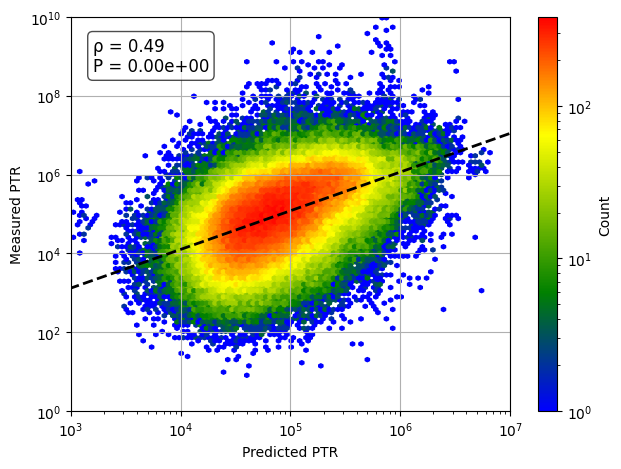

In [11]:

def hexbin(pred_file_path):
    
    pred_ptr_df = pd.read_csv(pred_file_path, sep='\t')
    print(pred_ptr_df)
    ptr = pred_ptr_df['PTR']
    ptr_pred = pred_ptr_df['predicted_PTR']
    rho, pval = spearmanr(ptr_pred, ptr)

    pred_exp = 10**ptr_pred
    
    ptr_exp = 10**ptr

    colors = [
        (0.0, "blue"),
        (0.3, "green"),
        (0.7, "yellow"),
        (1  , "red"),
    ]

    custom_cmap = LinearSegmentedColormap.from_list("blue_yellow_red", colors)

    hb =plt.hexbin(pred_exp, ptr_exp,gridsize=100, 
            xscale = 'log',yscale = 'log',cmap=custom_cmap, bins = 'log' ,mincnt=1  )

    


    m, b = np.polyfit(ptr_pred, ptr, 1)
    x_fit = np.linspace(ptr_pred.min(), ptr.max(), 100)
    y_fit = m * x_fit + b
    
    cb = plt.colorbar(hb)
    cb.set_label('Count')
    plt.plot(10**x_fit, 10**y_fit, color='black', linestyle='--', linewidth=2, label='Fit line')
    plt.xlim(1e3, 1e7)
    plt.ylim(1, 1e10)
    plt.text(
        0.05, 0.95, f'ρ = {float(rho):.2f}\nP = {float(pval):.2e}',
        transform=plt.gca().transAxes,
        fontsize=12,
        verticalalignment='top',
        bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.7)
    )
    plt.xlabel('Predicted PTR')
    plt.ylabel('Measured PTR')
    plt.grid()
    plt.tight_layout()
    filename = os.path.basename(pred_file_path)
    plt.savefig(f'plots/{filename}.png')
    plt.show()

hexbin('data/ptr_pred_esm2_t12_35M_UR50D_100_embed.tsv')